In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [43]:
IMBD_D = pd.read_csv(r"/content/IMDB Dataset.csv", engine='python', on_bad_lines='skip')
IMBD_D.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [44]:
IMBD_D.duplicated().sum()

np.int64(418)

In [45]:
IMBD_D.drop_duplicates(inplace=True)
IMBD_D.duplicated().sum()

np.int64(0)

In [46]:
IMBD_D.isnull().sum()

,0
review,0
sentiment,0


TEXT **PROCESSING**

In [47]:
from nltk.stem import WordNetLemmatizer
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

negation_words = {'not', 'no', 'never', 'neither', 'nor', 'but', 'however', 'although'}
final_stop_words = [word for word in stop_words if word not in negation_words]
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [48]:

def Tokenize(sentence):
    cleaned_sentence = re.sub(r"[^a-zA-Z0-9]", " ", sentence)
    return cleaned_sentence.lower().split()

Token = [Tokenize(sentence) for sentence in IMBD_D["review"]]

def Stop_rev_Word(tokens_list):
    return [word for word in tokens_list if word not in set(final_stop_words)]

Stop_Rev = [Stop_rev_Word(tokens) for tokens in Token]

def limm(W_):
    return [lemmatizer.lemmatize(word) for word in W_]

Lemmatize = [limm(W_) for W_ in Stop_Rev]

In [49]:
Sentences = [" ".join(words) for words in Lemmatize]

tf_idf = TfidfVectorizer(max_features=5000)
X_transformed = tf_idf.fit_transform(Sentences).toarray()

Target = IMBD_D["sentiment"].map({"positive": 1, "negative": 0})
train_X, test_X, train_Target, test_Target = train_test_split(X_transformed, Target, test_size=0.2, random_state=42)

X_tensor = torch.tensor(train_X, dtype=torch.float32)
Target_tensor = torch.tensor(train_Target.values, dtype=torch.float32).view(-1, 1)
test_X_tensor = torch.tensor(test_X, dtype=torch.float32)
test_Target_tensor = torch.tensor(test_Target.values, dtype=torch.float32).view(-1, 1)

Model = nn.Sequential(
    nn.Linear(5000, 32),
    nn.BatchNorm1d(32),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(32, 1),
    nn.Sigmoid()
)

lf = nn.BCELoss()
Optimizer = optim.Adam(Model.parameters(), lr=0.001)

epochs = 100
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for ep in range(epochs):
    Model.train()
    Target_Pred = Model(X_tensor)
    loss = lf(Target_Pred, Target_tensor)

    Optimizer.zero_grad()
    loss.backward()
    Optimizer.step()

    train_acc = ((Target_Pred.round() == Target_tensor).float().mean()).item()

    Model.eval()
    with torch.no_grad():
        Test_Pred = Model(test_X_tensor)
        test_loss = lf(Test_Pred, test_Target_tensor)
        test_acc = ((Test_Pred.round() == test_Target_tensor).float().mean()).item()

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    if (ep + 1) % 10 == 0:
        print(f"Epoch {ep + 1}/{epochs}, Train Loss: {loss.item():.4f}, Test Loss: {test_loss.item():.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

Epoch 10/100, Train Loss: 0.4053, Test Loss: 0.6833, Train Acc: 0.8750, Test Acc: 0.4984
Epoch 20/100, Train Loss: 0.3487, Test Loss: 0.6618, Train Acc: 0.9115, Test Acc: 0.6943
Epoch 30/100, Train Loss: 0.3140, Test Loss: 0.6279, Train Acc: 0.9263, Test Acc: 0.8340
Epoch 40/100, Train Loss: 0.2867, Test Loss: 0.5786, Train Acc: 0.9384, Test Acc: 0.8661
Epoch 50/100, Train Loss: 0.2646, Test Loss: 0.5113, Train Acc: 0.9464, Test Acc: 0.8740
Epoch 60/100, Train Loss: 0.2453, Test Loss: 0.4361, Train Acc: 0.9513, Test Acc: 0.8742
Epoch 70/100, Train Loss: 0.2295, Test Loss: 0.3782, Train Acc: 0.9550, Test Acc: 0.8729
Epoch 80/100, Train Loss: 0.2142, Test Loss: 0.3440, Train Acc: 0.9612, Test Acc: 0.8732
Epoch 90/100, Train Loss: 0.2022, Test Loss: 0.3324, Train Acc: 0.9636, Test Acc: 0.8710
Epoch 100/100, Train Loss: 0.1921, Test Loss: 0.3288, Train Acc: 0.9659, Test Acc: 0.8696


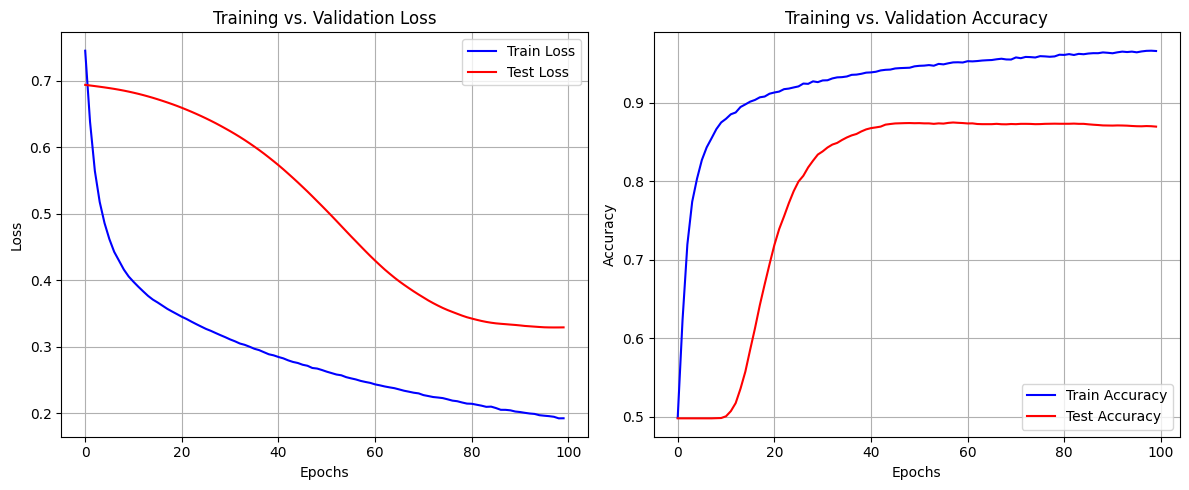

Final Test Accuracy: 0.8696
Final Test Loss: 0.3288


In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(test_losses, label='Test Loss', color='red')
plt.title('Training vs. Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy', color='blue')
plt.plot(test_accuracies, label='Test Accuracy', color='red')
plt.title('Training vs. Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


print(f"Final Test Accuracy: {test_accuracies[-1]:.4f}")
print(f"Final Test Loss: {test_losses[-1]:.4f}")

**EXP** **2**

In [51]:
Model_2 = nn.Sequential(
    nn.Linear(5000, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(64, 1),
    nn.Sigmoid()
)

lf = nn.BCELoss()
Optimizer_2 = optim.Adam(Model_2.parameters(),lr=0.0007)

epochs = 100

train_losses_2, test_losses_2 = [], []
train_accuracies_2, test_accuracies_2 = [], []

for ep in range(epochs):
    Model_2.train()
    Optimizer_2.zero_grad()

    Target_Pred_2 = Model_2(X_tensor)
    loss_2 = lf(Target_Pred_2, Target_tensor)

    loss_2.backward()
    Optimizer_2.step()

    train_acc_2 = ((Target_Pred_2.round() == Target_tensor).float().mean()).item()

    Model_2.eval()
    with torch.no_grad():
        Test_Pred_2 = Model_2(test_X_tensor)
        test_loss_2 = lf(Test_Pred_2, test_Target_tensor)
        test_acc_2 = ((Test_Pred_2.round() == test_Target_tensor).float().mean()).item()

    train_losses_2.append(loss_2.item())
    test_losses_2.append(test_loss_2.item())
    train_accuracies_2.append(train_acc_2)
    test_accuracies_2.append(test_acc_2)

    if (ep + 1) % 10 == 0:
        print(f"Exp 2 - Epoch {ep + 1}/{epochs} | Train Loss: {loss_2.item():.4f} | Test Loss: {test_loss_2.item():.4f} | Test Acc: {test_acc_2:.4f}")

Exp 2 - Epoch 10/100 | Train Loss: 0.3734 | Test Loss: 0.6819 | Test Acc: 0.5080
Exp 2 - Epoch 20/100 | Train Loss: 0.2967 | Test Loss: 0.6591 | Test Acc: 0.7745
Exp 2 - Epoch 30/100 | Train Loss: 0.2539 | Test Loss: 0.6247 | Test Acc: 0.8534
Exp 2 - Epoch 40/100 | Train Loss: 0.2235 | Test Loss: 0.5746 | Test Acc: 0.8667
Exp 2 - Epoch 50/100 | Train Loss: 0.1987 | Test Loss: 0.5059 | Test Acc: 0.8742
Exp 2 - Epoch 60/100 | Train Loss: 0.1789 | Test Loss: 0.4268 | Test Acc: 0.8761
Exp 2 - Epoch 70/100 | Train Loss: 0.1614 | Test Loss: 0.3563 | Test Acc: 0.8773
Exp 2 - Epoch 80/100 | Train Loss: 0.1475 | Test Loss: 0.3174 | Test Acc: 0.8763
Exp 2 - Epoch 90/100 | Train Loss: 0.1352 | Test Loss: 0.3046 | Test Acc: 0.8762
Exp 2 - Epoch 100/100 | Train Loss: 0.1247 | Test Loss: 0.3019 | Test Acc: 0.8761


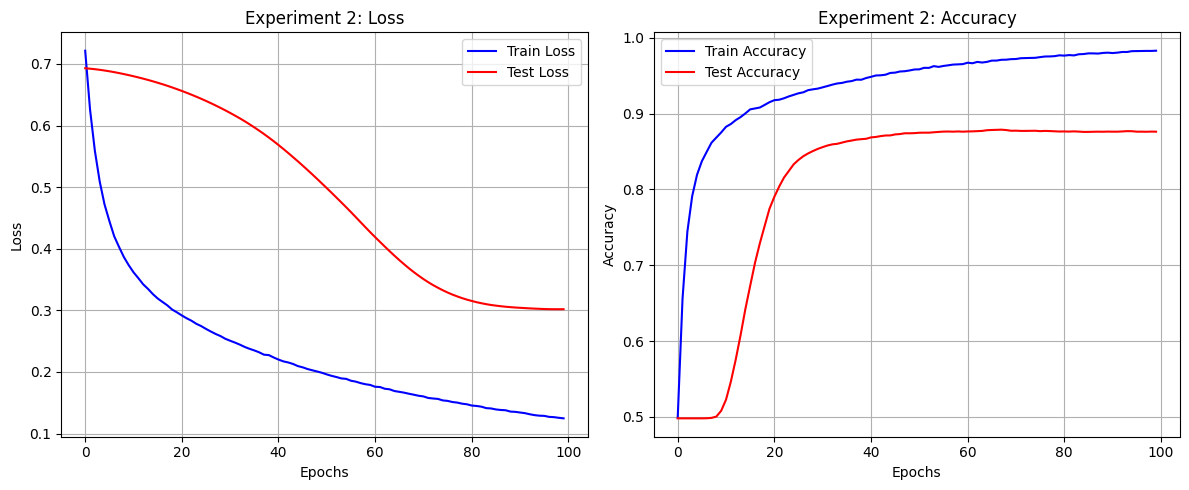

Exp 2 Final Test Accuracy: 0.8761
Exp 2 Final Test Loss: 0.3019


In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses_2, label='Train Loss', color='blue')
plt.plot(test_losses_2, label='Test Loss', color='red')
plt.title('Experiment 2: Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies_2, label='Train Accuracy', color='blue')
plt.plot(test_accuracies_2, label='Test Accuracy', color='red')
plt.title('Experiment 2: Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Exp 2 Final Test Accuracy: {test_accuracies_2[-1]:.4f}")
print(f"Exp 2 Final Test Loss: {test_losses_2[-1]:.4f}")

In [53]:
import pickle
import torch

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tf_idf, f)

torch.save(Model_2.state_dict(), 'sentiment_model.pth')
print("Saved Experiment 2 model (64 neurons) successfully!")

Saved Experiment 2 model (64 neurons) successfully!


In [ ]:
!pip install gradio --quiet

import gradio as gr
import torch
import torch.nn as nn
import pickle
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

vec = pickle.load(open('tfidf_vectorizer.pkl', 'rb'))
model = nn.Sequential(
    nn.Linear(5000, 64), nn.BatchNorm1d(64), nn.ReLU(),
    nn.Dropout(0.5), nn.Linear(64, 1), nn.Sigmoid()
)
model.load_state_dict(torch.load('sentiment_model.pth', map_location='cpu'))
model.eval()

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def clean_text(text):
    cleaned = re.sub(r"[^a-zA-Z0-9]", " ", text).lower().split()
    negation = {'not', 'no', 'never', 'but', 'however'}
    res = [lemmatizer.lemmatize(w) for w in cleaned if w not in stop_words or w in negation]
    return " ".join(res)

def predict_sentiment(user_input):
    if not user_input.strip():
        return {"Waiting for input...": 1.0}

    proc = clean_text(user_input)
    tensor_in = torch.tensor(vec.transform([proc]).toarray(), dtype=torch.float32)

    with torch.no_grad():
        prob = model(tensor_in).item()

    return {"🌟 Positive": prob, "😞 Negative": 1.0 - prob}

custom_theme = gr.themes.Monochrome(
    primary_hue="cyan",
    secondary_hue="blue",
).set(
    body_background_fill="#050505",
    body_text_color="#e0e0e0",
    block_background_fill="#111111",
    block_border_color="#00f2fe",
)

with gr.Blocks(theme=custom_theme) as demo:
    gr.Markdown("<h1 style='text-align: center; color: #00f2fe; margin-bottom: 0;'>Sentira-Torch AI</h1>")
    gr.Markdown("<p style='text-align: center; color: #888888; font-size: 16px;'>Advanced Neural Sentiment Analysis Engine</p>")

    with gr.Row():
        with gr.Column(scale=2):
            text_input = gr.Textbox(
                lines=6,
                placeholder="✍️ Enter a movie review or text stream here...",
                label="Input Stream"
            )
            analyze_btn = gr.Button("EXECUTE ANALYSIS", variant="primary")

        with gr.Column(scale=1):
            output_label = gr.Label(label="Analysis Result", num_top_classes=2)

    analyze_btn.click(fn=predict_sentiment, inputs=text_input, outputs=output_label)

demo.launch(share=True, debug=True)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
/tmp/ipykernel_5236/1671604550.py:54: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=custom_theme) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://100a177fc5699e2e9e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
